In [12]:
import numpy as np  
import matplotlib.pyplot as plt  
from mpl_toolkits.mplot3d import Axes3D  
from matplotlib.animation import FuncAnimation  
from matplotlib.patches import Rectangle
from scipy.stats import norm 

In [46]:
# 设置动图总帧数
# pre_frames = 3
# signal_frames = 20
# post_frames = 3
pre_frames = 30
s1_frames = 30
s2_frames = 120
post_frames = 30

In [31]:
s1_waveform = np.array([ 4.5426574e-02, -3.2646023e-03, -2.7213901e-02,  3.7188727e-02,
        3.4056567e-03, -3.5352828e-03, -1.2877061e-02, -3.7565241e-03,
       -2.2660974e-02, -1.0441732e-02,  2.5505755e-02, -4.1617807e-02,
       -2.3510497e-02, -2.0491362e-02,  1.6206183e-02,  3.0138226e-02,
        7.7306366e+01,  9.8529510e+01,  8.6087959e+01,  5.3637215e+01,
        3.1085455e+01,  3.2306061e+01,  1.6838421e+01,  1.2103635e+01,
        8.4367743e+00,  4.8642387e+00,  9.4497461e+00,  6.7753391e+00,
        6.4067578e+00,  1.0628740e+00,  8.8280857e-01,  2.2346182e+00,
        1.0399175e+00,  9.5682070e-03,  9.5962614e-01,  5.6720309e-02,
       -1.2538172e-02, -7.7020206e-02, -3.6420405e-02, -1.1284356e-01,
       -5.2739158e-02, -5.2340344e-02, -3.0846331e-02, -2.8458107e-02,
       -4.9952123e-02, -1.2934657e-02, -3.9205115e-02, -2.0099327e-02,
       -8.1582088e-03, -1.5322879e-02, -1.5322879e-02,  8.1577891e-01,
        1.0408830e-01, -1.7711103e-02,  1.5724026e-02, -1.0546433e-02,
       -8.1582088e-03, -9.9353772e-04,  3.7218038e-02, -1.5322880e-02])
s1_waveform = s1_waveform / np.sum(s1_waveform)
# s1_waveform = s1_waveform.reshape((20, 3)).mean(axis=1) 

# 定义高斯分布的参数  
mu = 0      # 均值  
sigma = 5   # 标准差  
  
# 创建一个x轴上的点集合  
x = np.linspace(-30, 30, 60)  
  
# 计算每个点的概率密度值  
se_waveform = norm.pdf(x, mu, sigma)
se_waveform = se_waveform / np.sum(se_waveform)

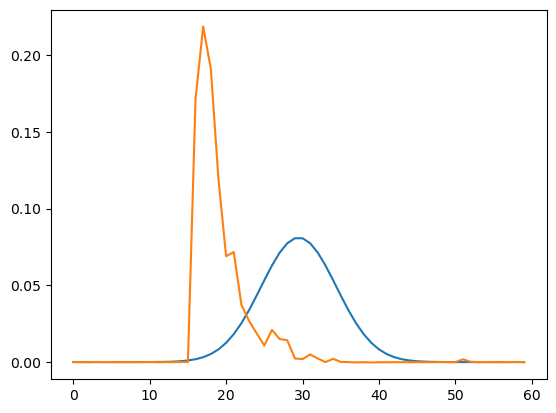

In [33]:
plt.plot(se_waveform)
plt.plot(s1_waveform)

In [159]:
num_electrons = 1000
electron_index = ((np.random.normal(1, 0.1, num_electrons) * signal_frames * (19/24)+ pre_frames + s1_frames) * 10).astype('int')

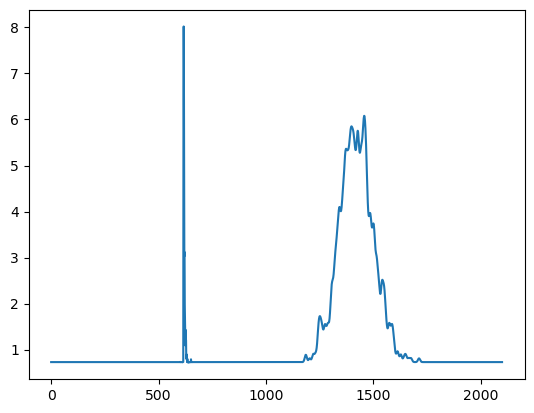

In [160]:
total_waveform = np.zeros(2100)
waveform_index = np.arange(2100)
total_waveform[600:660] += s1_waveform * num_electrons/30
for i in range(num_electrons):
    total_waveform[electron_index[i]:(electron_index[i] + 60)] += se_waveform
total_waveform = total_waveform + np.max(total_waveform) / 10
plt.plot(total_waveform)

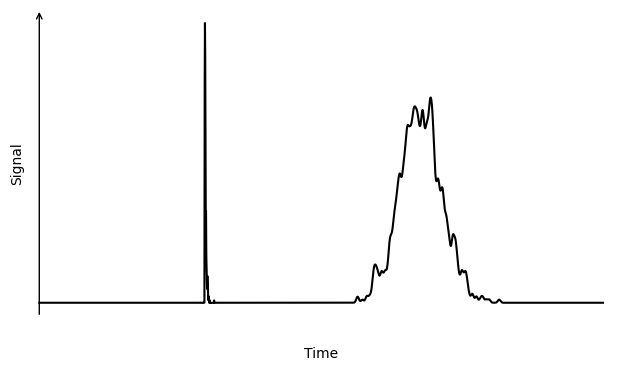

In [161]:
fig, ax = plt.subplots(figsize=(8,4))  
  
# 绘制波形  
ax.plot(waveform_index, total_waveform, color = 'black')  
  
# 隐藏 x 轴和 y 轴的刻度  
ax.xaxis.set_ticks_position('none')   
ax.yaxis.set_ticks_position('none')   
  
# 隐藏刻度标签  
ax.xaxis.set_ticklabels([])  
ax.yaxis.set_ticklabels([])  

ax.set_xlabel('Time')
ax.set_ylabel('Signal')
  
# 设置 x 轴和 y 轴为单箭头  
# 创建 x 轴箭头  
x_min, x_max = ax.get_xlim()  
ax.annotate(  
    '', xy=(x_max, 0), xytext=(x_min, 0),  
    arrowprops=dict(arrowstyle="->", lw=1)  
)  
  
# 创建 y 轴箭头  
y_min, y_max = ax.get_ylim()  
ax.annotate(  
    '', xy=(0, y_max), xytext=(0, y_min),  
    arrowprops=dict(arrowstyle="->", lw=1)  
)  
  
# 隐藏原始的 x 轴和 y 轴线  
ax.spines['left'].set_position('zero')  
ax.spines['left'].set_color('none')  
ax.spines['bottom'].set_position('zero')  
ax.spines['bottom'].set_color('none')  
ax.spines['right'].set_color('none')  
ax.spines['top'].set_color('none')  
  
# 设置箭头样式（可选，根据需要调整）  
ax.grid(False)  # 移除网格线  
  
plt.show()

0
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209


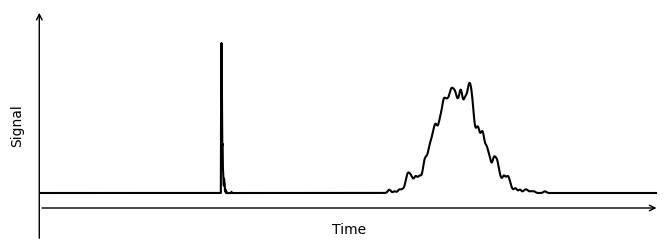

In [162]:
# 创建新的图形和3D坐标轴  
fig = plt.figure(figsize=(8,3))  
ax = fig.add_subplot(111)  

# 定义动态更新函数  
def update(frame): 
    ax.clear()
    print(frame)    
    # 绘制波形  
    ax.plot(waveform_index[:int(10 * frame)], total_waveform[:int(10 * frame)], color = 'black')  
      
    # 隐藏 x 轴和 y 轴的刻度  
    ax.xaxis.set_ticks_position('none')   
    ax.yaxis.set_ticks_position('none')   
      
    # 隐藏刻度标签  
    ax.xaxis.set_ticklabels([])  
    ax.yaxis.set_ticklabels([])  
    
    ax.set_xlabel('Time')
    ax.set_ylabel('Signal')

    # 设置坐标轴范围  
    ax.set_xlim(0, len(waveform_index))  
    ax.set_ylim(np.max(total_waveform) * -0.2, np.max(total_waveform) * 1.2)  
      
    # 设置 x 轴和 y 轴为单箭头  
    # 创建 x 轴箭头  
    x_min, x_max = ax.get_xlim()  
    ax.annotate(  
        '', xy=(x_max, 0), xytext=(x_min, 0),  
        arrowprops=dict(arrowstyle="->", lw=1)  
    )  
      
    # 创建 y 轴箭头  
    y_min, y_max = ax.get_ylim()  
    ax.annotate(  
        '', xy=(0, y_max), xytext=(0, y_min),  
        arrowprops=dict(arrowstyle="->", lw=1)  
    )  
      
    # 隐藏原始的 x 轴和 y 轴线  
    ax.spines['left'].set_position('zero')  
    ax.spines['left'].set_color('none')  
    ax.spines['bottom'].set_position('zero')  
    ax.spines['bottom'].set_color('none')  
    ax.spines['right'].set_color('none')  
    ax.spines['top'].set_color('none')  
      
    # 设置箭头样式（可选，根据需要调整）  
    ax.grid(False)  # 移除网格线  
      
    return ax  
  # 创建动画  
ani = FuncAnimation(fig, update, frames=pre_frames + s1_frames + s2_frames + post_frames, interval=33.3 , blit=False)  
  
# 保存动画为视频（需要ffmpeg）  
# ani.save('cylinder_with_moving_points.mp4', writer='ffmpeg', fps=20)  # 取消注释以保存为视频  
  
# 保存动画为动图  
ani.save('figure/waveform_s1_s2.gif', writer='imagemagick', fps=30)  

# 显示图形（可选，如果你只想保存而不显示）  
plt.show()

S2_only 波形
====

In [107]:
num_electrons = 4
electron_index = ((np.random.normal(1, 0.1, num_electrons) * signal_frames * (19/24)+ pre_frames + s1_frames) * 10).astype('int')

In [108]:
detection_line = np.ones(2100) * np.max(s1_waveform) * num_electrons/30 * 0.8 + np.max(total_waveform) / 10

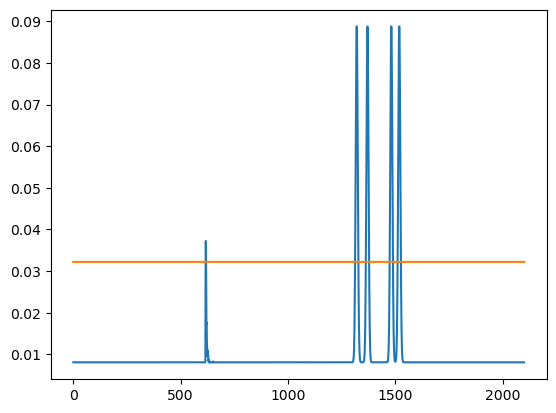

In [109]:
total_waveform = np.zeros(2100)
waveform_index = np.arange(2100)
total_waveform[600:660] += s1_waveform * num_electrons/30
for i in range(num_electrons):
    total_waveform[electron_index[i]:(electron_index[i] + 60)] += se_waveform
total_waveform = total_waveform + np.max(total_waveform) / 10
plt.plot(total_waveform)
plt.plot(detection_line)

0
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209


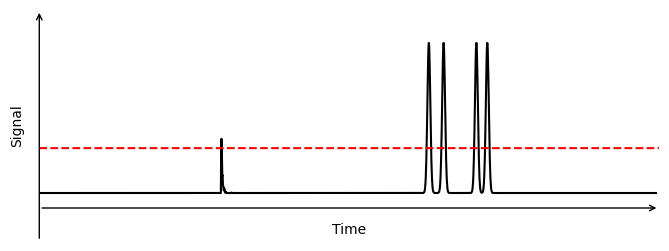

In [110]:
# 创建新的图形和3D坐标轴  
fig = plt.figure(figsize=(8,3))  
ax = fig.add_subplot(111)  

# 定义动态更新函数  
def update(frame): 
    ax.clear()
    print(frame)    
    # 绘制波形  
    ax.plot(waveform_index[:int(10 * frame)], total_waveform[:int(10 * frame)], color = 'black') 
    # 绘制探测线
    ax.plot(waveform_index, detection_line,'r--') 

      
    # 隐藏 x 轴和 y 轴的刻度  
    ax.xaxis.set_ticks_position('none')   
    ax.yaxis.set_ticks_position('none')   
      
    # 隐藏刻度标签  
    ax.xaxis.set_ticklabels([])  
    ax.yaxis.set_ticklabels([])  
    
    ax.set_xlabel('Time')
    ax.set_ylabel('Signal')

    # 设置坐标轴范围  
    ax.set_xlim(0, len(waveform_index))  
    ax.set_ylim(np.max(total_waveform) * -0.2, np.max(total_waveform) * 1.2)  
      
    # 设置 x 轴和 y 轴为单箭头  
    # 创建 x 轴箭头  
    x_min, x_max = ax.get_xlim()  
    ax.annotate(  
        '', xy=(x_max, 0), xytext=(x_min, 0),  
        arrowprops=dict(arrowstyle="->", lw=1)  
    )  
      
    # 创建 y 轴箭头  
    y_min, y_max = ax.get_ylim()  
    ax.annotate(  
        '', xy=(0, y_max), xytext=(0, y_min),  
        arrowprops=dict(arrowstyle="->", lw=1)  
    )  
      
    # 隐藏原始的 x 轴和 y 轴线  
    ax.spines['left'].set_position('zero')  
    ax.spines['left'].set_color('none')  
    ax.spines['bottom'].set_position('zero')  
    ax.spines['bottom'].set_color('none')  
    ax.spines['right'].set_color('none')  
    ax.spines['top'].set_color('none')  
      
    # 设置箭头样式（可选，根据需要调整）  
    ax.grid(False)  # 移除网格线  
      
    return ax  
  # 创建动画  
ani = FuncAnimation(fig, update, frames=pre_frames + s1_frames + s2_frames + post_frames, interval=33.3 , blit=False)  
  
# 保存动画为视频（需要ffmpeg）  
# ani.save('cylinder_with_moving_points.mp4', writer='ffmpeg', fps=20)  # 取消注释以保存为视频  
  
# 保存动画为动图  
ani.save('figure/waveform_s2_only.gif', writer='imagemagick', fps=30)  

# 显示图形（可选，如果你只想保存而不显示）  
plt.show()

Muon 波形
====

In [150]:
num_electrons = 10000
electron_index = ((np.random.normal(1, 0.2, num_electrons) * signal_frames * (12/24)+ pre_frames + s1_frames) * 10).astype('int')

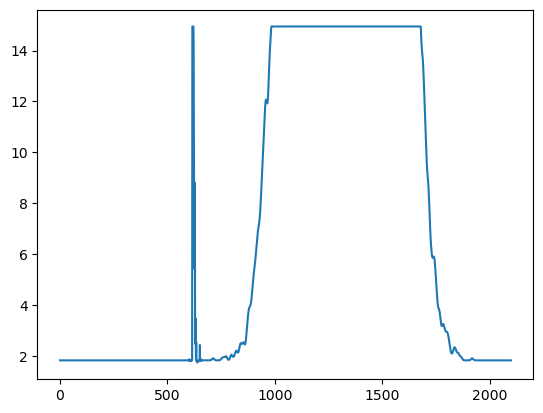

In [157]:
total_waveform = np.zeros(2100)
waveform_index = np.arange(2100)
total_waveform[600:660] += s1_waveform * num_electrons/30
for i in range(num_electrons):
    total_waveform[electron_index[i]:(electron_index[i] + 60)] += se_waveform
total_waveform = total_waveform + np.max(total_waveform) / 40

total_waveform[total_waveform > np.max(total_waveform) * 0.2] = np.max(total_waveform) * 0.2

total_waveform[1200:2000] = total_waveform[1000:1800]
total_waveform[1200:2000] = total_waveform[1000:1800]

plt.plot(total_waveform)

0
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209


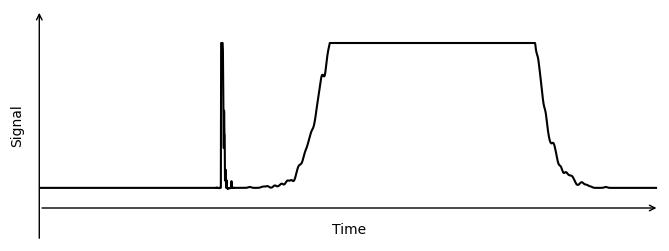

In [158]:
# 创建新的图形和3D坐标轴  
fig = plt.figure(figsize=(8,3))  
ax = fig.add_subplot(111)  

# 定义动态更新函数  
def update(frame): 
    ax.clear()
    print(frame)    
    # 绘制波形  
    ax.plot(waveform_index[:int(10 * frame)], total_waveform[:int(10 * frame)], color = 'black')  
      
    # 隐藏 x 轴和 y 轴的刻度  
    ax.xaxis.set_ticks_position('none')   
    ax.yaxis.set_ticks_position('none')   
      
    # 隐藏刻度标签  
    ax.xaxis.set_ticklabels([])  
    ax.yaxis.set_ticklabels([])  
    
    ax.set_xlabel('Time')
    ax.set_ylabel('Signal')

    # 设置坐标轴范围  
    ax.set_xlim(0, len(waveform_index))  
    ax.set_ylim(np.max(total_waveform) * -0.2, np.max(total_waveform) * 1.2)  
      
    # 设置 x 轴和 y 轴为单箭头  
    # 创建 x 轴箭头  
    x_min, x_max = ax.get_xlim()  
    ax.annotate(  
        '', xy=(x_max, 0), xytext=(x_min, 0),  
        arrowprops=dict(arrowstyle="->", lw=1)  
    )  
      
    # 创建 y 轴箭头  
    y_min, y_max = ax.get_ylim()  
    ax.annotate(  
        '', xy=(0, y_max), xytext=(0, y_min),  
        arrowprops=dict(arrowstyle="->", lw=1)  
    )  
      
    # 隐藏原始的 x 轴和 y 轴线  
    ax.spines['left'].set_position('zero')  
    ax.spines['left'].set_color('none')  
    ax.spines['bottom'].set_position('zero')  
    ax.spines['bottom'].set_color('none')  
    ax.spines['right'].set_color('none')  
    ax.spines['top'].set_color('none')  
      
    # 设置箭头样式（可选，根据需要调整）  
    ax.grid(False)  # 移除网格线  
      
    return ax  
  # 创建动画  
ani = FuncAnimation(fig, update, frames=pre_frames + s1_frames + s2_frames + post_frames, interval=33.3 , blit=False)  
  
# 保存动画为视频（需要ffmpeg）  
# ani.save('cylinder_with_moving_points.mp4', writer='ffmpeg', fps=20)  # 取消注释以保存为视频  
  
# 保存动画为动图  
ani.save('figure/waveform_muon.gif', writer='imagemagick', fps=30)  

# 显示图形（可选，如果你只想保存而不显示）  
plt.show()

延迟电子波形
====

一个frame为50个waveform_index

In [102]:
DE_Frame = np.array([ 50 ,24 ,49 ,18,   2,  65, 117,  11,  90,  65, 119 , 32,  19 , 67 , 27,  62 ,105 , 93,7 , 66,  13, 111])

In [124]:
DE_waveform_index = (np.random.rand(len(DE_Frame)) * 50 ).astype('int')
DE_waveform_index = DE_waveform_index + DE_Frame * 50
frame_index = np.arange(150*50)
DE_waveform = np.zeros(frame_index.shape)

In [125]:
DE_waveform_index

array([2509, 1245, 2454,  916,  101, 3272, 5895,  596, 4500, 3299, 5953,
       1646,  954, 3374, 1368, 3132, 5272, 4682,  355, 3312,  668, 5594])

In [165]:
np.random.normal(1,0.25)

1.1737052168299005

In [166]:
for i in DE_waveform_index:
    DE_waveform[i:(i + 60)] += se_waveform * np.random.normal(1,0.25)
DE_waveform = DE_waveform + np.max(DE_waveform)* 0.2

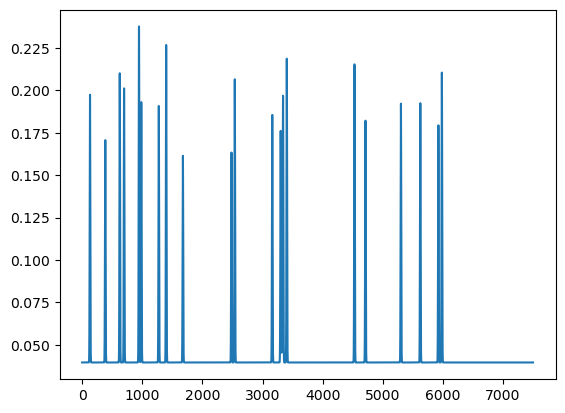

In [167]:
plt.plot(DE_waveform)

0
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149


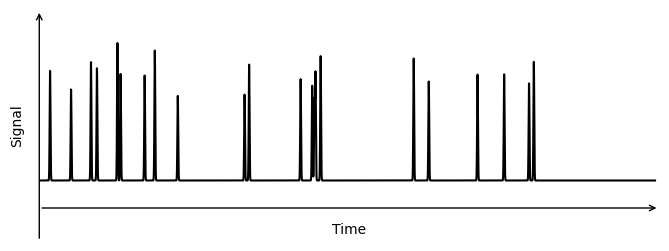

In [168]:
# 创建新的图形和3D坐标轴  
fig = plt.figure(figsize=(8,3))  
ax = fig.add_subplot(111)  

# 定义动态更新函数  
def update(frame): 
    ax.clear()
    print(frame)    
    # 绘制波形  
    ax.plot(frame_index[:int(50 * frame)], DE_waveform[:int(50 * frame)], color = 'black') 
    # 绘制探测线
    # ax.plot(waveform_index, detection_line,'r--') 

      
    # 隐藏 x 轴和 y 轴的刻度  
    ax.xaxis.set_ticks_position('none')   
    ax.yaxis.set_ticks_position('none')   
      
    # 隐藏刻度标签  
    ax.xaxis.set_ticklabels([])  
    ax.yaxis.set_ticklabels([])  
    
    ax.set_xlabel('Time')
    ax.set_ylabel('Signal')

    # 设置坐标轴范围  
    ax.set_xlim(0, len(frame_index))  
    ax.set_ylim(np.max(DE_waveform) * -0.2, np.max(DE_waveform) * 1.2)  
      
    # 设置 x 轴和 y 轴为单箭头  
    # 创建 x 轴箭头  
    x_min, x_max = ax.get_xlim()  
    ax.annotate(  
        '', xy=(x_max, 0), xytext=(x_min, 0),  
        arrowprops=dict(arrowstyle="->", lw=1)  
    )  
      
    # 创建 y 轴箭头  
    y_min, y_max = ax.get_ylim()  
    ax.annotate(  
        '', xy=(0, y_max), xytext=(0, y_min),  
        arrowprops=dict(arrowstyle="->", lw=1)  
    )  
      
    # 隐藏原始的 x 轴和 y 轴线  
    ax.spines['left'].set_position('zero')  
    ax.spines['left'].set_color('none')  
    ax.spines['bottom'].set_position('zero')  
    ax.spines['bottom'].set_color('none')  
    ax.spines['right'].set_color('none')  
    ax.spines['top'].set_color('none')  
      
    # 设置箭头样式（可选，根据需要调整）  
    ax.grid(False)  # 移除网格线  
      
    return ax  
  # 创建动画  
ani = FuncAnimation(fig, update, frames=150, interval=33.3 , blit=False)  
  
# 保存动画为视频（需要ffmpeg）  
# ani.save('cylinder_with_moving_points.mp4', writer='ffmpeg', fps=20)  # 取消注释以保存为视频  
  
# 保存动画为动图  
ani.save('figure/waveform_DE.gif', writer='imagemagick', fps=30)  

# 显示图形（可选，如果你只想保存而不显示）  
plt.show()